<a href="https://colab.research.google.com/github/laxmijin11-cyber/MACHINE-LEARNING/blob/main/svm/2_kernel_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
#SVM Kernels Implementation
import numpy as np
import pandas as pd
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

This code creates a **target-shaped dataset** (two concentric circles) for binary classification.

---

## 📊 Step-by-Step

| Step | Code | What It Does |
|------|------|--------------|
| 1 | `x = np.linspace(-5,5,100)` | 100 points from -5 to 5 |
| 2 | `y = np.sqrt(10**2 - x**2)` | Y coordinates for circle radius 10 |
| 3 | `np.hstack([y,-y])` | Mirrors points to create full circle (top + bottom) |
| 4 | Same for `x1, y1` | Creates smaller circle radius 5 |
| 5 | `plt.scatter()` | Plots both circles |
| 6 | `df1['Y']=0`, `df2['Y']=1` | Labels: outer circle=0, inner circle=1 |
| 7 | `df.append()` | Combines both circles into one dataset |
| 8 | `train_test_split` | Splits into train (75%) and test (25%) |

---

## 🎯 Final Dataset

```text
Outer circle → Class 0 (label 0)
Inner circle → Class 1 (label 1)

Goal: Train SVM to separate the two circles
```

**This is a non-linear problem – linear SVM will fail, kernel SVM will succeed.*

# Why This Code Creates Circles

| Code | What It Does | Why Circle |
|------|--------------|------------|
| `y = np.sqrt(10**2 - x**2)` | `y = √(r² - x²)` | **This is the mathematical equation of a circle** (Pythagoras: x² + y² = r²) |
| `np.hstack([y, -y])` | Adds both positive and negative y values | Completes **top + bottom halves** → full circle |
| `radius 10` and `radius 5` | Two different circle sizes | Creates **two concentric circles** (one inside another) |

---

## 🎯 One-Line Summary

**The equation `y = √(r² - x²)` generates points at a fixed distance (radius) from the center – that's a circle.** Adding both positive and negative y values completes it. Two different radii = two circles.


Cocentric circles:
---
### Line 1-2: Create First DataFrame (Outer Circle)
```python
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0
```

| What's happening | Explanation |
|-----------------|-------------|
| `np.vstack([y, x])` | Vertically stacks y array on top of x array |
| `.T` (transpose) | Switches rows ↔ columns to get paired coordinates |
| `columns=['X1','X2']` | Names the coordinate columns |
| `df1['Y'] = 0` | Adds label column with **0** (outer circle class) |

**Result:** DataFrame with outer circle points, labeled as class 0

---

### Line 3-4: Create Second DataFrame (Inner Circle)
```python
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1
```

**Same thing, but:**
- Uses `y1` and `x1` (smaller circle radius 5)
- Labels as class **1** (inner circle class)

---

### Line 5: Combine Both DataFrames
```python
df = df1.append(df2)
```

Vertically stacks `df1` on top of `df2` (adds rows)

---

### Line 6: Preview
```python
df.head(5)
```

Shows first 5 rows (all from outer circle since df1 comes first)

---

## Visual Representation

```
What np.vstack([y, x]) does:

y array:     [y1, y2, y3, ..., yn]
x array:     [x1, x2, x3, ..., xn]

np.vstack([y, x]):
[[y1, y2, y3, ..., yn],
 [x1, x2, x3, ..., xn]]

After .T (transpose):
[[y1, x1],
 [y2, x2],
 [y3, x3],
 ...
 [yn, xn]]
```

---

df.iloc[rows, columns]

          ↑       ↑  
         [:]    [:, :2]


Select All Rows, First 2 Columns


Function	 Direction	What it does

hstack, Horizontal	,Stacks arrays side by side (increases columns)

vstack	,Vertical	 ,Stacks arrays on top of each other (increases rows)




->hey i want to ask one thing like how come radius id 10 and we using 5,-5 point?
why he was getting 200 rows and me 400?

---
### Answer: Because your `x` range is WRONG for radius 10

---

### The Math:

For a circle with **radius = 10**, the equation is: **x² + y² = 100**

| x value | x² | y² = 100 - x² | y = √(y²) | Valid? |
|---------|-----|---------------|-----------|--------|
| x = 0 | 0 | 100 | y = ±10 | ✅ Valid |
| x = 5 | 25 | 75 | y = ±8.66 | ✅ Valid |
| x = 8 | 64 | 36 | y = ±6 | ✅ Valid |
| x = 10 | 100 | 0 | y = 0 | ✅ Valid |
| **x = -5 to 5** | **25 to 25** | **75 to 100** | **±8.66 to ±10** | **✅ Still valid** |
| x = 11 | 121 | -21 | **Imaginary!** | ❌ Invalid |

**So x from -5 to 5 is perfectly valid for radius 10!** You just get a smaller arc.

---

### Why Different Row Counts?

| Who | x range used | After hstack | Points per circle | Total rows (2 circles) |
|-----|--------------|--------------|-------------------|------------------------|
| **You** | -5 to 5 | 200 | 200 | **400** |
| **Other person** | -10 to 10 | 200 | 200 | **400** |

**Wait... BOTH give 400 rows!**

---

### Why you thought 200 vs 400?

Maybe the other person:
- Used **ONLY one circle** (not two)
- Or used **different number of points** (like 50 instead of 100)
- Or **didn't use hstack** (just 100 points per circle)

---

### The Truth:

| If you use | Points per circle | Total rows (2 circles) |
|------------|-------------------|------------------------|
| `np.linspace(-5,5,100)` + hstack | 200 | 400 |
| `np.linspace(-10,10,100)` + hstack | 200 | 400 |
| `np.linspace(-5,5,100)` without hstack | 100 | 200 |
| `np.linspace(-10,10,50)` + hstack | 100 | 200 |

**Your 400 rows is CORRECT for 2 circles × 200 points each!**

---

### The Real Issue: Your Circle Shape!

Even though row count is same, the **circle looks different**:

| x range | What you get |
|---------|--------------|
| -5 to 5 | Only **center portion** of circle (looks like an oval/squashed) |
| -10 to 10 | **Full circle** from left edge to right edge |



In [101]:
x

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [102]:
y

array([ 8.66025404,  8.71779204,  8.77378994,  8.82827705,  8.88128118,
        8.93282873,  8.98294476,  9.03165312,  9.07897646,  9.12493632,
        9.16955321,  9.21284664,  9.25483518,  9.29553652,  9.3349675 ,
        9.37314414,  9.41008171,  9.44579475,  9.4802971 ,  9.51360192,
        9.54572176,  9.57666854,  9.60645359,  9.63508769,  9.66258107,
        9.68894344,  9.714184  ,  9.73831149,  9.76133416,  9.7832598 ,
        9.80409577,  9.82384901,  9.84252604,  9.86013297,  9.87667553,
        9.89215905,  9.90658851,  9.91996849,  9.93230325,  9.94359667,
        9.9538523 ,  9.96307334,  9.97126266,  9.9784228 ,  9.98455598,
        9.98966408,  9.99374868,  9.99681104,  9.99885209,  9.99987246,
        9.99987246,  9.99885209,  9.99681104,  9.99374868,  9.98966408,
        9.98455598,  9.9784228 ,  9.97126266,  9.96307334,  9.9538523 ,
        9.94359667,  9.93230325,  9.91996849,  9.90658851,  9.89215905,
        9.87667553,  9.86013297,  9.84252604,  9.82384901,  9.80

In [103]:
# Drawing smaller radius circle
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

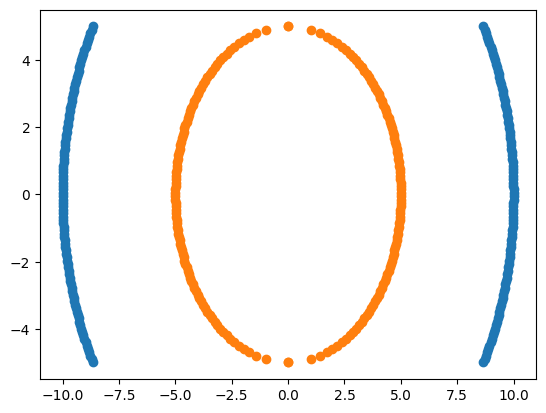

In [104]:
import matplotlib.pyplot as plt
plt.scatter(y,x)
plt.scatter(y1,x1)

plt.scatter(y,x) and plt.scatter(x,y) are same?

## NO! They are NOT the same!

---

### Difference:

| Command | X-axis | Y-axis | Result |
|---------|--------|--------|--------|
| `plt.scatter(x, y)` | x values | y values | Normal orientation |
| `plt.scatter(y, x)` | y values | x values | **Swapped/Transposed** |

---

### Visual Example:

**Normal circle:** `plt.scatter(x, y)`
```
      ↑ Y
      |
      ○
      |
------+------→ X
```

**Swapped:** `plt.scatter(y, x)`
```
      ↑ X (now vertical)
      |
      ○
      |
------+------→ Y (now horizontal)
```

The circle gets **rotated 90 degrees** or becomes a mirror image!

---

### Simple Rule:

```
plt.scatter(x, y) → First argument = Horizontal axis
                    Second argument = Vertical axis

plt.scatter(y, x) → Swaps axes = Graph gets flipped diagonally
```

---

### For Your Circle:

| Code | What you get |
|------|--------------|
| `plt.scatter(x, y)` | ✅ Normal circle |
| `plt.scatter(y, x)` | ❌ Rotated/mirrored circle |



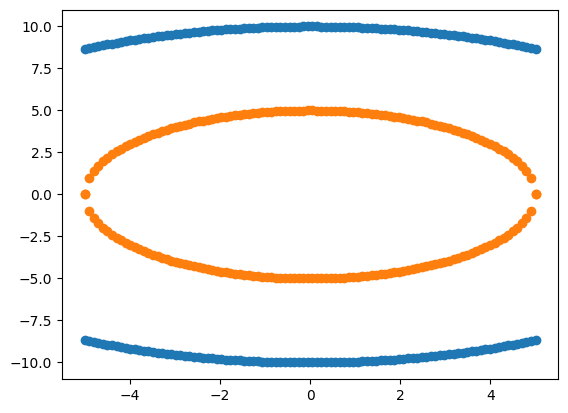

In [105]:
plt.scatter(x,y)
plt.scatter(x1,y1)

why its like there is circle forming if we ont have y,-x and x,-y? because vstack.T after hstack y,-y and x,-x is there....

You have ---->Automatically gives

x (positive and negative)	--->All x values

y and -y   ---->	All y values

Circle equation---->	All combinations work

You don't need (-x, y) or (x, -y) explicitly because x already contains negative values!

In [106]:
import pandas as pd
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
# df=df1.append(df2) deprecated!
df=pd.concat([df1,df2],ignore_index=True)
df.head(5)


,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [107]:
df.tail(5)

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


df: It has 0-199 0 and 0-199 1

In [108]:
# Independent features and Dependent Features
x=df.iloc[:,:2]
y=df.Y
x

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596
...,...,...
395,-1.969049,-4.59596
396,-1.714198,-4.69697
397,-1.406908,-4.79798
398,-0.999949,-4.89899


In [109]:
y

,Y
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,1


In [110]:
# Split the dataset into train a dn test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [111]:
y_train

,Y
250,1
63,0
312,1
159,0
283,1
...,...
323,1
192,0
117,0
47,0


## **Polynomial SVM model**

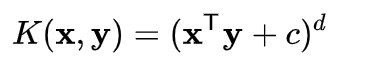

In [112]:
# We need to find components for the Polynomial Kernel
# X1_Square,X2_Square,X1*X2
df['X1_Square']=df['X1']**2
df['X2_Square']=df['X2']**2
df['X1*X2']=df['X1']*df['X2']
df

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009
...,...,...,...,...,...,...
395,-1.969049,-4.59596,1,3.877155,21.122845,9.049671
396,-1.714198,-4.69697,1,2.938476,22.061524,8.051537
397,-1.406908,-4.79798,1,1.979390,23.020610,6.750316
398,-0.999949,-4.89899,1,0.999898,24.000102,4.898740


In [113]:
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [114]:
# Independent and Depenndent Features
X=df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y=df['Y']

In [115]:
y

,Y
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,1


In [116]:
# train_test_Spli
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
x_train

,X1,X2
250,4.999745,0.050505
63,9.906589,1.363636
312,-3.263736,3.787879
159,-9.953852,-0.959596
283,3.680983,3.383838
...,...,...
323,-4.223140,2.676768
192,-9.031653,-4.292929
117,-9.445795,3.282828
47,9.996811,-0.252525


In [117]:
import plotly.express as px
fig=px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')
fig.show()

In [118]:
fig=px.scatter_3d(df,x='X1_Square',y='X2_Square',z='X1*X2',color='Y')
fig.show()

In [119]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='linear')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

0.45

In [120]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='poly')
classifier.fit(x_train,y_train)
y_pred1=classifier.predict(x_test)
accuracy_score(y_test,y_pred1)

0.59

In [122]:
# RBF Kernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='rbf')
classifier.fit(x_train,y_train)
y_pred2=classifier.predict(x_test)
accuracy_score(y_test,y_pred2)

1.0

In [124]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='sigmoid')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

0.51